# DIGITRA — Model 1 / Custom CNN — RAM Düzeltilmiş + Model 2 Devam Sürümü

**Colab'da ilk iş:** `File → Save a copy in Drive`

Bu sürüm:
- `BATCH_SIZE=32`
- shuffle'ı görüntü decode edilmeden önce yapar
- `num_parallel_calls=4`
- `prefetch(1)`
- kayıtlı split varsa audit/SHA/pHash/near-duplicate/split işlemlerini tekrar yapmaz
- her epoch sonunda `latest_model.keras` kaydeder
- en iyi modeli ayrıca `best_model.keras` tutar
- training logunu `append=True` ile korur
- runtime kapanırsa checkpoint ve logdan devam etmeye çalışır


## 🚀 YARIN HIZLI DEVAM

Bu notebook artık **Model 2 — EfficientNetB0** için güvenli devam akışına göre düzenlendi.

**Yarın eski audit / SHA-256 / pHash / Custom CNN eğitim hücrelerini tekrar çalıştırma.** Notebook'un en altındaki **“MODEL 2 — YARIN BURADAN DEVAM ET”** bölümüne git ve hücreleri sırayla çalıştır.

- Drive’daki mevcut splitler yeniden kullanılacak.
- Dataset A yalnızca train/validation/test için tekrar runtime’a indirilecek; pahalı audit tekrarlanmayacak.
- `latest_model.keras` varsa EfficientNet kaldığı epoch’tan devam edecek.
- `CSVLogger append=True` olduğu için önceki eğitim logu silinmeyecek.
- GPU yoksa eğitim hücresi kendini durduracak; yanlışlıkla saatlerce CPU eğitimi başlamayacak.
- Dataset B **eğitim/fine-tuning için kullanılmayacak**; yalnızca Model 2 tamamlandıktan sonra harici test için kullanılacak.

**Ekran Kartı Durum Kontrolü**


In [1]:
!nvidia-smi

Sat Aug 22 16:23:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**Kaggle Kütüphanesini Kurulumu**

In [1]:
!pip install -q kagglehub

**Dataset Kurulumu ve Eklenmesi**

In [2]:
import kagglehub
import os

dataset_a = kagglehub.dataset_download(
    "grassknoted/asl-alphabet"
)

dataset_path = dataset_a

train_path = os.path.join(
    dataset_path,
    "asl_alphabet_train",
    "asl_alphabet_train"
)

print("Dataset indirildi.")
print("Dataset yolu:")
print(dataset_path)
print("\nTrain yolu:")
print(train_path)
print("\nTrain klasörü mevcut mu:", os.path.exists(train_path))


100%|██████████| 1.03G/1.03G [00:43<00:00, 25.1MB/s]

Extracting files...


Dataset indirildi.
Dataset yolu:
/root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1

Train yolu:
/root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1/asl_alphabet_train/asl_alphabet_train

Train klasörü mevcut mu: True


**Klasör Yapısının Takibi ve Gösterimi**

In [4]:
import os

print("Dataset kökü:", dataset_path)

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    subindent = "    " * (level + 1)

    for file in files[:5]:
        print(f"{subindent}{file}")

    if level >= 2:
        dirs[:] = []


Dataset kökü: /kaggle/input/asl-alphabet
asl-alphabet/
    asl_alphabet_test/
        asl_alphabet_test/
            A_test.jpg
            E_test.jpg
            L_test.jpg
            N_test.jpg
            S_test.jpg
    asl_alphabet_train/
        asl_alphabet_train/


**Sınıfları ve görüntü sayılarını kontrol et**

In [5]:
import os

classes = sorted([
    name for name in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, name))
])

print("Toplam sınıf sayısı:", len(classes))
print("\nSınıflar:")
print(classes)

print("\nSınıf başına görüntü sayıları:")

total_images = 0

for class_name in classes:
    class_path = os.path.join(train_path, class_name)

    image_count = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    total_images += image_count
    print(f"{class_name}: {image_count}")

print("\nToplam görüntü:", total_images)


Toplam sınıf sayısı: 29

Sınıflar:
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']

Sınıf başına görüntü sayıları:
A: 3000
B: 3000
C: 3000
D: 3000
E: 3000
F: 3000
G: 3000
H: 3000
I: 3000
J: 3000
K: 3000
L: 3000
M: 3000
N: 3000
O: 3000
P: 3000
Q: 3000
R: 3000
S: 3000
T: 3000
U: 3000
V: 3000
W: 3000
X: 3000
Y: 3000
Z: 3000
del: 3000
nothing: 3000
space: 3000

Toplam görüntü: 87000


**Dataset Manifest + Bozuk Görüntü Kontrolü**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

project_path = "/content/drive/MyDrive/Digitra"

folders = [
    "manifests",
    "splits",
    "models",
    "reports",
    "experiments",
    "exports",
    "logs"
]

os.makedirs(project_path, exist_ok=True)

for folder in folders:
    os.makedirs(
        os.path.join(project_path, folder),
        exist_ok=True
    )

print("Digitra klasörleri hazır.")

Digitra klasörleri hazır.


## OTURUM KURTARMA / HIZLI DEVAM

Drive'da daha önce oluşturulmuş split dosyaları varsa pahalı veri hazırlama adımları
tekrar yapılmaz.

Bu sayede runtime kapanırsa tekrar 87.000 görsel audit, SHA-256, pHash,
near-duplicate taraması ve yeniden split yapmazsın.


In [7]:
import os
import pandas as pd

PROJECT_PATH = "/content/drive/MyDrive/Digitra"
MANIFEST_PATH = os.path.join(PROJECT_PATH, "manifests", "dataset_a_manifest.csv")

TRAIN_SPLIT_PATH = os.path.join(PROJECT_PATH, "splits", "train_manifest.csv")
VAL_SPLIT_PATH = os.path.join(PROJECT_PATH, "splits", "val_manifest.csv")
TEST_SPLIT_PATH = os.path.join(PROJECT_PATH, "splits", "test_manifest.csv")

CROSS_LABEL_REPORT_PATH = os.path.join(
    PROJECT_PATH, "reports", "cross_label_phash_groups.csv"
)

FAST_RESTORE = all(
    os.path.exists(p)
    for p in [TRAIN_SPLIT_PATH, VAL_SPLIT_PATH, TEST_SPLIT_PATH]
)

def repair_runtime_paths(df):
    df = df.copy()

    if "filename" not in df.columns or "label" not in df.columns:
        raise ValueError("Split manifestinde filename/label sütunları bulunamadı.")

    df["filepath"] = df.apply(
        lambda row: os.path.join(
            train_path,
            str(row["label"]),
            str(row["filename"])
        ),
        axis=1
    )
    return df

if FAST_RESTORE:
    print("✅ KAYITLI SPLITLER BULUNDU — HIZLI DEVAM MODU")

    train_df = repair_runtime_paths(pd.read_csv(TRAIN_SPLIT_PATH))
    val_df = repair_runtime_paths(pd.read_csv(VAL_SPLIT_PATH))
    test_df = repair_runtime_paths(pd.read_csv(TEST_SPLIT_PATH))

    if os.path.exists(MANIFEST_PATH):
        manifest = repair_runtime_paths(pd.read_csv(MANIFEST_PATH))
        print("✅ Manifest Drive'dan yüklendi:", len(manifest))
    else:
        manifest = None
        print("⚠️ Manifest bulunamadı; splitler yine de kullanılabilir.")

    print("Train:", len(train_df))
    print("Validation:", len(val_df))
    print("Test:", len(test_df))
    print("İlk train dosyası mevcut mu:", os.path.exists(train_df.iloc[0]["filepath"]))
else:
    print("ℹ️ Kayıtlı split bulunamadı.")
    print("İlk çalıştırma modu kullanılacak.")


✅ KAYITLI SPLITLER BULUNDU — HIZLI DEVAM MODU
✅ Manifest Drive'dan yüklendi: 87000
Train: 60900
Validation: 13050
Test: 13050
İlk train dosyası mevcut mu: True


In [9]:
import os
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

if FAST_RESTORE:
    print("⏭️ Audit atlandı: kayıtlı split/manifest kullanılıyor.")
else:
    manifest_data = []
    classes = sorted(os.listdir(train_path))

    for class_name in classes:
        class_path = os.path.join(train_path, class_name)

        if not os.path.isdir(class_path):
            continue

        files = os.listdir(class_path)

        for file_name in tqdm(files, desc=f"Kontrol: {class_name}"):
            file_path = os.path.join(class_path, file_name)

            if not file_name.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            try:
                file_size = os.path.getsize(file_path)

                with Image.open(file_path) as img:
                    width, height = img.size
                    channels = len(img.getbands())
                    img.verify()

                manifest_data.append({
                    "filepath": file_path,
                    "filename": file_name,
                    "label": class_name,
                    "width": width,
                    "height": height,
                    "channels": channels,
                    "filesize": file_size,
                    "valid": True,
                    "error": ""
                })
            except Exception as e:
                manifest_data.append({
                    "filepath": file_path,
                    "filename": file_name,
                    "label": class_name,
                    "width": None,
                    "height": None,
                    "channels": None,
                    "filesize": None,
                    "valid": False,
                    "error": str(e)
                })


⏭️ Audit atlandı: kayıtlı split/manifest kullanılıyor.


**Dataframe haline getiriliyor**

In [10]:
import pandas as pd

if not FAST_RESTORE:
    manifest = pd.DataFrame(manifest_data)
    manifest.to_csv(MANIFEST_PATH, index=False)

print("Toplam kayıt:", len(manifest))
print("Geçerli görüntü:", int(manifest["valid"].astype(bool).sum()))
print("Bozuk görüntü:", int((~manifest["valid"].astype(bool)).sum()))
print("\nManifest yolu:")
print(MANIFEST_PATH)


Toplam kayıt: 87000
Geçerli görüntü: 87000
Bozuk görüntü: 0

Manifest yolu:
/content/drive/MyDrive/Digitra/manifests/dataset_a_manifest.csv


**Exact Duplicate Kontrolü**

In [11]:
import hashlib
from tqdm.auto import tqdm

def sha256_file(file_path):
    sha256 = hashlib.sha256()
    with open(file_path, "rb") as f:
        while True:
            chunk = f.read(1024 * 1024)
            if not chunk:
                break
            sha256.update(chunk)
    return sha256.hexdigest()

sha_ready = (
    "sha256" in manifest.columns
    and manifest["sha256"].notna().all()
)

if sha_ready:
    print("⏭️ SHA-256 zaten mevcut; yeniden hesaplanmadı.")
else:
    sha256_values = []

    for file_path in tqdm(
        manifest["filepath"],
        desc="SHA-256 hesaplanıyor"
    ):
        sha256_values.append(sha256_file(file_path))

    manifest["sha256"] = sha256_values
    manifest.to_csv(MANIFEST_PATH, index=False)
    print("✅ SHA-256 tamamlandı.")


⏭️ SHA-256 zaten mevcut; yeniden hesaplanmadı.


In [12]:
duplicate_mask = manifest.duplicated(
    subset=["sha256"],
    keep=False
)

exact_duplicates = manifest[
    duplicate_mask
].copy()

print("Duplicate olan toplam dosya:", len(exact_duplicates))

duplicate_group_count = (
    exact_duplicates["sha256"].nunique()
)

print("Duplicate grup sayısı:", duplicate_group_count)

Duplicate olan toplam dosya: 0
Duplicate grup sayısı: 0


In [13]:
duplicate_path = os.path.join(
    PROJECT_PATH, "reports", "exact_duplicates.csv"
)

exact_duplicates.to_csv(duplicate_path, index=False)
manifest.to_csv(MANIFEST_PATH, index=False)

print("Duplicate raporu:", duplicate_path)
print("Manifest güncellendi:", MANIFEST_PATH)


Duplicate raporu: /content/drive/MyDrive/Digitra/reports/exact_duplicates.csv
Manifest güncellendi: /content/drive/MyDrive/Digitra/manifests/dataset_a_manifest.csv


In [14]:
duplicate_mask = manifest.duplicated(
    subset=["sha256"],
    keep=False
)

exact_duplicates = manifest[
    duplicate_mask
].copy()

print("Duplicate olan toplam dosya:", len(exact_duplicates))
print("Duplicate grup sayısı:", exact_duplicates["sha256"].nunique())

Duplicate olan toplam dosya: 0
Duplicate grup sayısı: 0


**pHash hesapla**

In [15]:
!pip install -q ImageHash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.0 MB/s eta 0:00:00


In [16]:
import imagehash
from PIL import Image
from tqdm.auto import tqdm

phash_ready = (
    "phash" in manifest.columns
    and manifest["phash"].notna().all()
)

if phash_ready:
    print("⏭️ pHash zaten mevcut; yeniden hesaplanmadı.")
else:
    phash_values = []

    for file_path in tqdm(
        manifest["filepath"],
        desc="pHash hesaplanıyor"
    ):
        try:
            with Image.open(file_path) as img:
                phash_values.append(str(imagehash.phash(img.convert("RGB"))))
        except Exception:
            phash_values.append(None)

    manifest["phash"] = phash_values
    print("pHash hesaplama tamamlandı.")
    print("Toplam:", len(manifest))
    print("pHash üretilemeyen:", manifest["phash"].isna().sum())


⏭️ pHash zaten mevcut; yeniden hesaplanmadı.


In [17]:
manifest.to_csv(MANIFEST_PATH, index=False)
print("pHash değerleri manifest'e kaydedildi.")
print(MANIFEST_PATH)


pHash değerleri manifest'e kaydedildi.
/content/drive/MyDrive/Digitra/manifests/dataset_a_manifest.csv


**Near-duplicate Bulma**

In [18]:
!pip install -q pybktree

  Preparing metadata (setup.py) ... done


In [19]:
import pybktree
from tqdm.auto import tqdm

PHASH_DISTANCE = 4

def hamming_distance(a, b):
    return (a ^ b).bit_count()

if FAST_RESTORE and os.path.exists(CROSS_LABEL_REPORT_PATH):
    near_duplicates = None
    print("⏭️ Near-duplicate taraması tekrar çalıştırılmadı.")
    print("Mevcut rapor:", CROSS_LABEL_REPORT_PATH)
else:
    tree = pybktree.BKTree(hamming_distance)
    near_duplicates = []

    for index, row in tqdm(
        manifest.iterrows(),
        total=len(manifest),
        desc="Near-duplicate aranıyor"
    ):
        hash_int = int(row["phash"], 16)

        for distance, matched_hash in tree.find(hash_int, PHASH_DISTANCE):
            near_duplicates.append({
                "index": index,
                "filepath": row["filepath"],
                "label": row["label"],
                "phash": row["phash"],
                "matched_phash": format(matched_hash, "016x"),
                "distance": distance
            })

        tree.add(hash_int)

    print("Near-duplicate aday sayısı:", len(near_duplicates))


⏭️ Near-duplicate taraması tekrar çalıştırılmadı.
Mevcut rapor: /content/drive/MyDrive/Digitra/reports/cross_label_phash_groups.csv


**pHash mesafelerini say**

In [20]:
from collections import Counter

if near_duplicates is None:
    print("⏭️ Mesafe dağılımı atlandı; önceki oturumun raporu kullanılacak.")
else:
    distance_counts = Counter(
        item["distance"] for item in near_duplicates
    )

    print("pHash mesafe dağılımı:")

    for distance in sorted(distance_counts):
        print(f"Distance {distance}: {distance_counts[distance]} eşleşme")


⏭️ Mesafe dağılımı atlandı; önceki oturumun raporu kullanılacak.


**Aynı pHash farklı sınıflarda mı?**

In [21]:
phash_groups = (
    manifest
    .groupby("phash")
    .agg(
        image_count=("filepath", "count"),
        label_count=("label", "nunique")
    )
    .reset_index()
)

# Aynı pHash'e sahip birden fazla görüntü
same_phash_groups = phash_groups[
    phash_groups["image_count"] > 1
]

# Aynı pHash fakat farklı sınıflar
cross_label_groups = same_phash_groups[
    same_phash_groups["label_count"] > 1
]

print(
    "Birden fazla görüntü içeren aynı pHash grup sayısı:",
    len(same_phash_groups)
)

print(
    "Aynı pHash olup farklı sınıflara yayılan grup sayısı:",
    len(cross_label_groups)
)

print(
    "Bu cross-label gruplardaki toplam görüntü:",
    manifest[
        manifest["phash"].isin(
            cross_label_groups["phash"]
        )
    ].shape[0]
)

Birden fazla görüntü içeren aynı pHash grup sayısı: 14710
Aynı pHash olup farklı sınıflara yayılan grup sayısı: 282
Bu cross-label gruplardaki toplam görüntü: 1701


**Cross-label pHash Gruplama**

In [22]:
cross_label_images = manifest[
    manifest["phash"].isin(cross_label_groups["phash"])
].copy()

cross_label_images = cross_label_images.sort_values(
    ["phash", "label", "filepath"]
)

cross_label_images.to_csv(
    CROSS_LABEL_REPORT_PATH,
    index=False
)

print("Cross-label görüntü sayısı:", len(cross_label_images))
print(
    "Cross-label pHash grup sayısı:",
    cross_label_images["phash"].nunique()
)

print("\nRapor kaydedildi:")
print(CROSS_LABEL_REPORT_PATH)

display(
    cross_label_images[
        ["phash", "label", "filename"]
    ].head(30)
)


Cross-label görüntü sayısı: 1701
Cross-label pHash grup sayısı: 282

Rapor kaydedildi:
/content/drive/MyDrive/Digitra/reports/cross_label_phash_groups.csv


,phash,label,filename
32882,a24d56312e5bd4b3,K,K2033.jpg
32856,a24d56312e5bd4b3,K,K2034.jpg
32341,a24d56312e5bd4b3,K,K2035.jpg
32802,a24d56312e5bd4b3,K,K2036.jpg
53564,a24d56312e5bd4b3,R,R2002.jpg
52686,a24d56312e5bd4b3,R,R2003.jpg
30793,a34c36330e5bd693,K,K2448.jpg
53224,a34c36330e5bd693,R,R2345.jpg
52765,a34c36330e5bd693,R,R2346.jpg
51868,a34c36330e5bd693,R,R2347.jpg


**GerçeK Görsel Olarak Bakmak**

pHash: a24d56312e5bd4b3
Sınıflar: ['K', 'R']


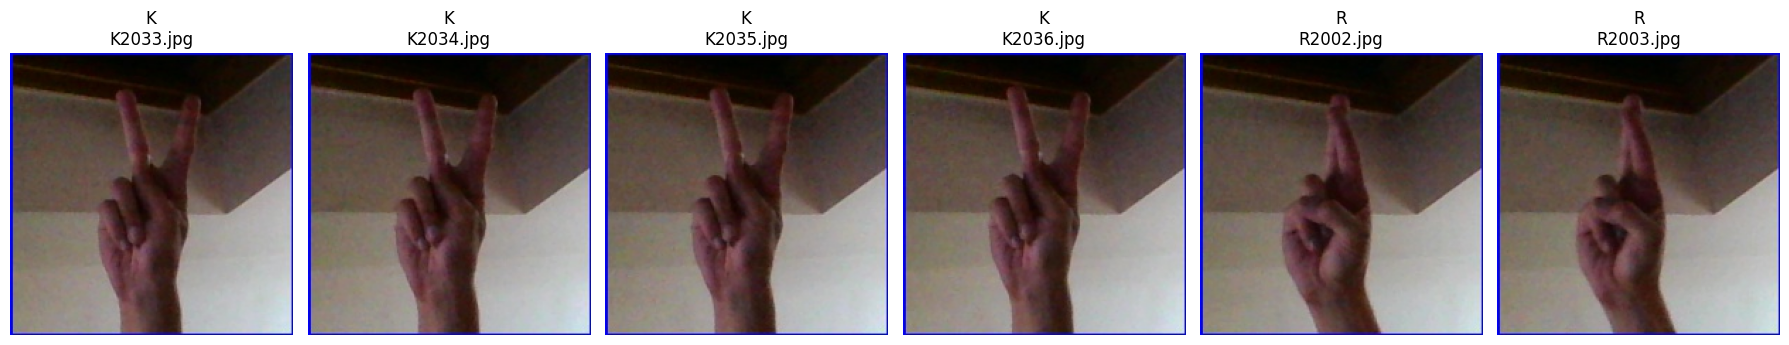

pHash: a34c36330e5bd693
Sınıflar: ['K', 'R']


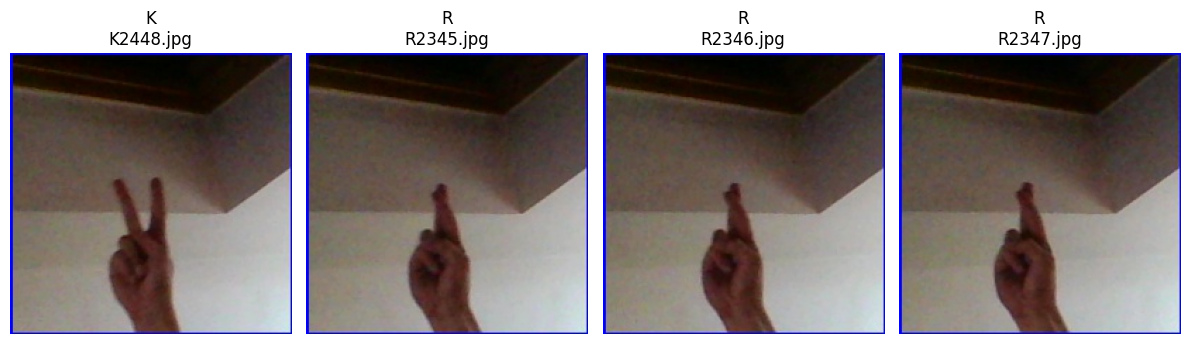

pHash: a45b36292e5b5785
Sınıflar: ['B', 'E']


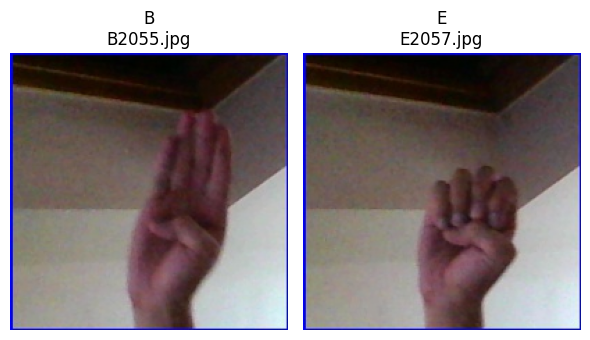

pHash: a45b4db60b5653a5
Sınıflar: ['I', 'R']


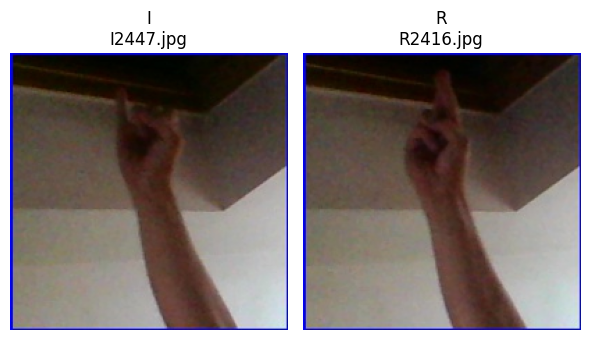

pHash: a55a14292e5b57ad
Sınıflar: ['B', 'W']


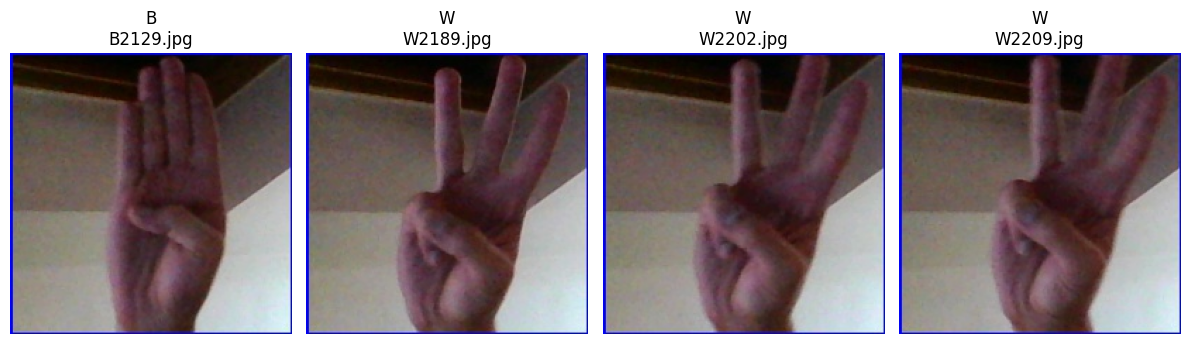

pHash: a55a16292e5b57a5
Sınıflar: ['B', 'W']


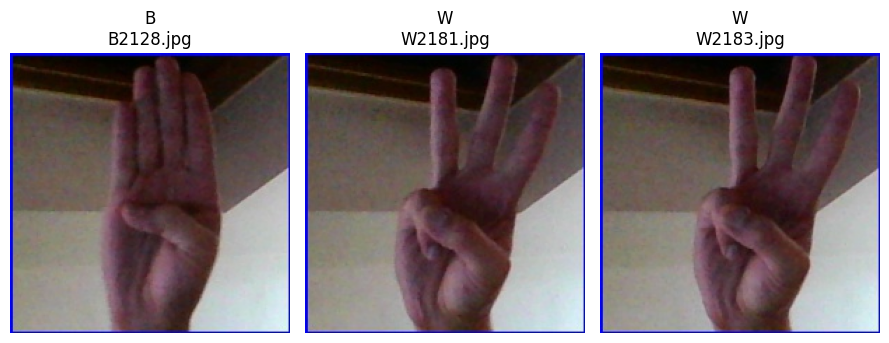

In [23]:
import matplotlib.pyplot as plt
from PIL import Image

# Farklı label içeren ilk 6 pHash grubu
sample_phashes = (
    cross_label_images["phash"]
    .drop_duplicates()
    .head(6)
    .tolist()
)

for phash in sample_phashes:

    group = cross_label_images[
        cross_label_images["phash"] == phash
    ].head(8)

    print("=" * 80)
    print("pHash:", phash)
    print("Sınıflar:", group["label"].unique().tolist())
    print("=" * 80)

    n = len(group)

    plt.figure(figsize=(3 * n, 4))

    for i, (_, row) in enumerate(group.iterrows()):

        img = Image.open(row["filepath"]).convert("RGB")

        plt.subplot(1, n, i + 1)
        plt.imshow(img)

        plt.title(
            f'{row["label"]}\n{row["filename"]}'
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

**Temiz Manifeste Aktarım**

In [24]:
clean_manifest = manifest[
    manifest["valid"] == True
].copy()

clean_manifest = clean_manifest.reset_index(drop=True)

print("Split için kullanılacak toplam görüntü:", len(clean_manifest))
print("Sınıf sayısı:", clean_manifest["label"].nunique())

Split için kullanılacak toplam görüntü: 87000
Sınıf sayısı: 29


**Train ve Test Aşaması**

In [25]:
from sklearn.model_selection import train_test_split

SEED = 42

if FAST_RESTORE:
    print("⏭️ Split yeniden oluşturulmadı.")
    print("Train:", len(train_df))
    print("Validation:", len(val_df))
    print("Test:", len(test_df))
else:
    train_df, temp_df = train_test_split(
        clean_manifest,
        test_size=0.30,
        random_state=SEED,
        stratify=clean_manifest["label"]
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=SEED,
        stratify=temp_df["label"]
    )

    print("Train:", len(train_df))
    print("Validation:", len(val_df))
    print("Test:", len(test_df))

    print("\nOranlar:")
    print("Train:", len(train_df) / len(clean_manifest))
    print("Validation:", len(val_df) / len(clean_manifest))
    print("Test:", len(test_df) / len(clean_manifest))


⏭️ Split yeniden oluşturulmadı.
Train: 60900
Validation: 13050
Test: 13050


**Leakage / Overlap kontrolü**

In [26]:
# Dosya yolu overlap kontrolü
train_paths = set(train_df["filepath"])
val_paths = set(val_df["filepath"])
test_paths = set(test_df["filepath"])

print(
    "Train-Val dosya overlap:",
    len(train_paths.intersection(val_paths))
)

print(
    "Train-Test dosya overlap:",
    len(train_paths.intersection(test_paths))
)

print(
    "Val-Test dosya overlap:",
    len(val_paths.intersection(test_paths))
)


# SHA-256 overlap kontrolü
train_hashes = set(train_df["sha256"])
val_hashes = set(val_df["sha256"])
test_hashes = set(test_df["sha256"])

print()
print(
    "Train-Val SHA256 overlap:",
    len(train_hashes.intersection(val_hashes))
)

print(
    "Train-Test SHA256 overlap:",
    len(train_hashes.intersection(test_hashes))
)

print(
    "Val-Test SHA256 overlap:",
    len(val_hashes.intersection(test_hashes))
)

Train-Val dosya overlap: 0
Train-Test dosya overlap: 0
Val-Test dosya overlap: 0

Train-Val SHA256 overlap: 0
Train-Test SHA256 overlap: 0
Val-Test SHA256 overlap: 0


**Split manifestlerini Drive’a kaydetme**

In [5]:
split_columns = [
    "filepath", "filename", "label",
    "width", "height", "channels",
    "filesize", "sha256", "phash", "valid"
]

train_df[split_columns].to_csv(TRAIN_SPLIT_PATH, index=False)
val_df[split_columns].to_csv(VAL_SPLIT_PATH, index=False)
test_df[split_columns].to_csv(TEST_SPLIT_PATH, index=False)

print("Train manifest:", TRAIN_SPLIT_PATH)
print("Validation manifest:", VAL_SPLIT_PATH)
print("Test manifest:", TEST_SPLIT_PATH)

print()
print("Train kayıt:", len(train_df))
print("Validation kayıt:", len(val_df))
print("Test kayıt:", len(test_df))


NameError: name 'train_df' is not defined

**CNN için Preprocessing**

In [8]:
import tensorflow as tf
import numpy as np
import random

SEED = 42
IMG_SIZE = 224

# RAM güvenliği
BATCH_SIZE = 32

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("GPU:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
Image size: 224
Batch size: 32
GPU: []


**Label Numaralandırma**

In [9]:
class_names = sorted(train_df["label"].unique())

class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

index_to_class = {
    index: class_name
    for class_name, index in class_to_index.items()
}

NUM_CLASSES = len(class_names)

print("Toplam sınıf:", NUM_CLASSES)
print("\nLabel mapping:")

for class_name, index in class_to_index.items():
    print(f"{index:2d} -> {class_name}")

Toplam sınıf: 29

Label mapping:
 0 -> A
 1 -> B
 2 -> C
 3 -> D
 4 -> E
 5 -> F
 6 -> G
 7 -> H
 8 -> I
 9 -> J
10 -> K
11 -> L
12 -> M
13 -> N
14 -> O
15 -> P
16 -> Q
17 -> R
18 -> S
19 -> T
20 -> U
21 -> V
22 -> W
23 -> X
24 -> Y
25 -> Z
26 -> del
27 -> nothing
28 -> space


**Görüntüyü CNN'e Hazırlama**

In [10]:
def load_image(file_path, label):
    image = tf.io.read_file(file_path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE],
        antialias=True
    )

    image = tf.cast(image, tf.float32)

    # 0..255 -> 0..1 dönüşümü model içindeki Rescaling katmanında.
    return image, label


**Train / Validation / Test Oluşturma**

In [11]:
def create_dataset(dataframe, training=False):
    file_paths = dataframe["filepath"].astype(str).values

    labels = (
        dataframe["label"]
        .map(class_to_index)
        .values
        .astype("int32")
    )

    ds = tf.data.Dataset.from_tensor_slices(
        (file_paths, labels)
    )

    # KRİTİK RAM DÜZELTMESİ:
    # Önce sadece path/label shuffle edilir.
    # Görüntüler henüz RAM'e decode edilmez.
    if training:
        ds = ds.shuffle(
            buffer_size=5000,
            seed=SEED,
            reshuffle_each_iteration=True
        )

    # Shuffle'dan SONRA görüntüyü aç.
    ds = ds.map(
        load_image,
        num_parallel_calls=4
    )

    ds = ds.batch(
        BATCH_SIZE,
        drop_remainder=False
    )

    # RAM'i sınırlamak için AUTOTUNE yerine 1 batch.
    ds = ds.prefetch(1)

    return ds


In [12]:
train_ds = create_dataset(
    train_df,
    training=True
)

val_ds = create_dataset(
    val_df,
    training=False
)

test_ds = create_dataset(
    test_df,
    training=False
)

print("Datasetler oluşturuldu.")

Datasetler oluşturuldu.


**Çalışmasının Kontrol Edilmesi**

In [33]:
images, labels = next(
    iter(train_ds)
)

print("Image batch shape:")
print(images.shape)

print("\nLabel batch shape:")
print(labels.shape)

print("\nPixel minimum:")
print(tf.reduce_min(images).numpy())

print("\nPixel maximum:")
print(tf.reduce_max(images).numpy())

print("\nİlk 10 label:")
print(labels[:10].numpy())

Image batch shape:
(32, 224, 224, 3)

Label batch shape:
(32,)

Pixel minimum:
0.0

Pixel maximum:
255.0

İlk 10 label:
[ 1 11  8 15  3 14 24  2  5 22]


**Train-Only Augmentation**

In [34]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision

data_augmentation = keras.Sequential(
    [
        layers.RandomRotation(
            0.05,
            seed=SEED
        ),

        layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05,
            seed=SEED
        ),

        layers.RandomZoom(
            height_factor=0.10,
            width_factor=0.10,
            seed=SEED
        ),

        layers.RandomContrast(
            factor=0.10,
            seed=SEED
        ),
    ],
    name="data_augmentation"
)

print("Augmentation hazır.")

Augmentation hazır.


**Custom CNN Oluşturma**

In [35]:
inputs = keras.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3),
    name="image_input"
)

# Augmentation
x = data_augmentation(inputs)

# 0..255 -> 0..1
x = layers.Rescaling(
    1.0 / 255.0,
    name="rescaling"
)(x)


# -------------------------
# CONV BLOCK 1
# -------------------------

x = layers.Conv2D(
    32,
    kernel_size=3,
    padding="same",
    use_bias=False
)(x)

x = layers.BatchNormalization()(x)

x = layers.Activation(
    "relu"
)(x)

x = layers.MaxPooling2D(
    pool_size=2
)(x)


# -------------------------
# CONV BLOCK 2
# -------------------------

x = layers.Conv2D(
    64,
    kernel_size=3,
    padding="same",
    use_bias=False
)(x)

x = layers.BatchNormalization()(x)

x = layers.Activation(
    "relu"
)(x)

x = layers.MaxPooling2D(
    pool_size=2
)(x)


# -------------------------
# CONV BLOCK 3
# -------------------------

x = layers.Conv2D(
    128,
    kernel_size=3,
    padding="same",
    use_bias=False
)(x)

x = layers.BatchNormalization()(x)

x = layers.Activation(
    "relu"
)(x)

x = layers.MaxPooling2D(
    pool_size=2
)(x)


# -------------------------
# CONV BLOCK 4
# -------------------------

x = layers.Conv2D(
    256,
    kernel_size=3,
    padding="same",
    use_bias=False
)(x)

x = layers.BatchNormalization()(x)

x = layers.Activation(
    "relu"
)(x)

x = layers.MaxPooling2D(
    pool_size=2
)(x)


# -------------------------
# CLASSIFIER
# -------------------------

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(
    0.35
)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="predictions"
)(x)


model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="digitra_custom_cnn_v1"
)

print("Model oluşturuldu.")

Model oluşturuldu.


**Modeli Derleme**

In [36]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss=keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        "accuracy"
    ]
)

print("Model compile edildi.")

Model compile edildi.


**Modelin Özeti:**

In [37]:
model.summary()

Model: "digitra_custom_cnn_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 397,309 (1.52 MB)

 Trainable params: 396,349 (1.51 MB)

 Non-trainable params: 960 (3.75 KB)

**Training Hazırlığı**

In [38]:
import os

model_dir = "/content/drive/MyDrive/Digitra/models/digitra-cnn-v1.0.0"
log_dir = "/content/drive/MyDrive/Digitra/logs"

os.makedirs(model_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

best_model_path = os.path.join(model_dir, "best_model.keras")
latest_model_path = os.path.join(model_dir, "latest_model.keras")
training_log_path = os.path.join(log_dir, "digitra_cnn_v1_training.csv")

print("Model klasörü:", model_dir)
print("Best model:", best_model_path)
print("Latest model:", latest_model_path)
print("Training log:", training_log_path)


Model klasörü: /content/drive/MyDrive/Digitra/models/digitra-cnn-v1.0.0
Best model: /content/drive/MyDrive/Digitra/models/digitra-cnn-v1.0.0/best_model.keras
Latest model: /content/drive/MyDrive/Digitra/models/digitra-cnn-v1.0.0/latest_model.keras
Training log: /content/drive/MyDrive/Digitra/logs/digitra_cnn_v1_training.csv


**Callbacks Oluştur**

In [39]:
from tensorflow import keras

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    # Her epoch sonunda son model.
    keras.callbacks.ModelCheckpoint(
        filepath=latest_model_path,
        save_best_only=False,
        save_freq="epoch",
        verbose=0
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    keras.callbacks.CSVLogger(
        training_log_path,
        append=True
    )
]

print("✅ Callbacks hazır.")


✅ Callbacks hazır.


## Eğitim Çökerse Otomatik Devam

`latest_model.keras` varsa onu yükler. Yoksa `best_model.keras` denenir.
Training CSV'sinden tamamlanan epoch sayısı okunur.


In [40]:
import os
import pandas as pd
from tensorflow import keras

resume_path = None

if os.path.exists(latest_model_path):
    resume_path = latest_model_path
elif os.path.exists(best_model_path):
    resume_path = best_model_path

if resume_path is not None:
    model = keras.models.load_model(resume_path)
    print("✅ Önceki checkpoint yüklendi:")
    print(resume_path)
else:
    print("ℹ️ Önceki checkpoint yok; yeni model kullanılacak.")

INITIAL_EPOCH = 0

if os.path.exists(training_log_path):
    try:
        previous_log = pd.read_csv(training_log_path)

        if "epoch" in previous_log.columns and len(previous_log) > 0:
            INITIAL_EPOCH = int(previous_log["epoch"].max()) + 1
        elif len(previous_log) > 0:
            INITIAL_EPOCH = int(len(previous_log))
    except Exception as e:
        print("⚠️ Training log okunamadı:", e)
        INITIAL_EPOCH = 0

print("Başlangıç epoch:", INITIAL_EPOCH)


ℹ️ Önceki checkpoint yok; yeni model kullanılacak.
⚠️ Training log okunamadı: No columns to parse from file
Başlangıç epoch: 0


İlk Eğitimin Başlatılması

In [ ]:
EPOCHS = 30

if INITIAL_EPOCH >= EPOCHS:
    print(
        f"✅ {INITIAL_EPOCH} epoch zaten tamamlanmış. "
        f"EPOCHS={EPOCHS}; eğitim yeniden başlatılmadı."
    )
else:
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        initial_epoch=INITIAL_EPOCH,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )


Epoch 1/30
1042/1904 ━━━━━━━━━━━━━━━━━━━━ 1:52 131ms/step - accuracy: 0.9973 - loss: 0.0128

**Test İşlemi**

In [13]:
from tensorflow import keras

best_model_path = (
    "/content/drive/MyDrive/Digitra/"
    "models/digitra-cnn-v1.0.0/"
    "best_model.keras"
)

best_model = keras.models.load_model(best_model_path)

print("✅ En iyi model yüklendi.")

test_loss, test_accuracy = best_model.evaluate(
    test_ds,
    verbose=1
)

print("\n===== TEST SONUCU =====")
print(f"Test Accuracy : %{test_accuracy * 100:.4f}")
print(f"Test Loss     : {test_loss:.6f}")

✅ En iyi model yüklendi.
408/408 ━━━━━━━━━━━━━━━━━━━━ 378s 923ms/step - accuracy: 0.9998 - loss: 0.0018

===== TEST SONUCU =====
Test Accuracy : %99.9847
Test Loss     : 0.001832


**Yanlış Sınıflandırmaları Bul**

In [14]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Gerçek label'lar
y_true = np.concatenate([
    labels.numpy()
    for _, labels in test_ds
])

# Model tahminleri
y_prob = best_model.predict(
    test_ds,
    verbose=1
)

y_pred = np.argmax(
    y_prob,
    axis=1
)

# Yanlış tahmin sayısı
wrong_indices = np.where(
    y_true != y_pred
)[0]

print("\n==============================")
print("YANLIŞ TAHMİN SAYISI")
print("==============================")

print(len(wrong_indices))

print("\n==============================")
print("CLASSIFICATION REPORT")
print("==============================")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

# Confusion Matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

print("\nConfusion Matrix hazır.")
print("Shape:", cm.shape)

408/408 ━━━━━━━━━━━━━━━━━━━━ 373s 912ms/step

YANLIŞ TAHMİN SAYISI
2

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           A     1.0000    1.0000    1.0000       450
           B     1.0000    1.0000    1.0000       450
           C     1.0000    1.0000    1.0000       450
           D     1.0000    1.0000    1.0000       450
           E     1.0000    1.0000    1.0000       450
           F     1.0000    1.0000    1.0000       450
           G     1.0000    1.0000    1.0000       450
           H     1.0000    1.0000    1.0000       450
           I     1.0000    1.0000    1.0000       450
           J     1.0000    1.0000    1.0000       450
           K     1.0000    1.0000    1.0000       450
           L     1.0000    1.0000    1.0000       450
           M     0.9956    1.0000    0.9978       450
           N     1.0000    0.9956    0.9978       450
           O     1.0000    1.0000    1.0000       450
           P     1.0000    1.0000    1.0000

Yanlış olan harfi ne kadar iyi öğrendiğini kontrol ediyoruz (M harfi)

Toplam yanlış: 2


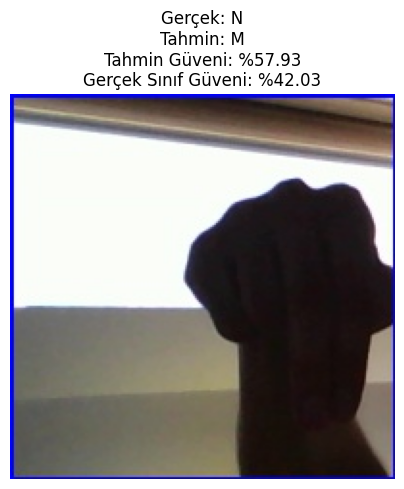

Dosya: /root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1/asl_alphabet_train/asl_alphabet_train/N/N2584.jpg
Gerçek: N
Tahmin: M
Tahmin güveni: %57.9305
Gerçek sınıf güveni: %42.0311

En yüksek 5 tahmin:
M        %57.9305
N        %42.0311
J        %0.0266
L        %0.0042
O        %0.0037


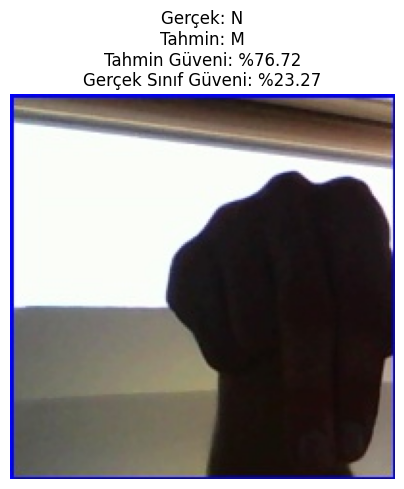

Dosya: /root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1/asl_alphabet_train/asl_alphabet_train/N/N2843.jpg
Gerçek: N
Tahmin: M
Tahmin güveni: %76.7250
Gerçek sınıf güveni: %23.2708

En yüksek 5 tahmin:
M        %76.7250
N        %23.2708
J        %0.0028
L        %0.0006
O        %0.0005


In [15]:
import matplotlib.pyplot as plt
import numpy as np

print("Toplam yanlış:", len(wrong_indices))

for i, wrong_idx in enumerate(wrong_indices):

    # Test dataframe'indeki ilgili satır
    row = test_df.iloc[wrong_idx]

    image_path = row["filepath"]

    true_index = y_true[wrong_idx]
    pred_index = y_pred[wrong_idx]

    true_class = class_names[true_index]
    pred_class = class_names[pred_index]

    confidence = y_prob[wrong_idx][pred_index]

    true_confidence = y_prob[wrong_idx][true_index]

    # Görüntüyü yükle
    image = plt.imread(image_path)

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")

    plt.title(
        f"Gerçek: {true_class}\n"
        f"Tahmin: {pred_class}\n"
        f"Tahmin Güveni: %{confidence * 100:.2f}\n"
        f"Gerçek Sınıf Güveni: %{true_confidence * 100:.2f}"
    )

    plt.show()

    print("Dosya:", image_path)
    print("Gerçek:", true_class)
    print("Tahmin:", pred_class)
    print(f"Tahmin güveni: %{confidence * 100:.4f}")
    print(f"Gerçek sınıf güveni: %{true_confidence * 100:.4f}")

    # En yüksek 5 tahmin
    top5 = np.argsort(y_prob[wrong_idx])[-5:][::-1]

    print("\nEn yüksek 5 tahmin:")

    for index in top5:
        print(
            f"{class_names[index]:8s} "
            f"%{y_prob[wrong_idx][index] * 100:.4f}"
        )

    print("=" * 50)

**Ayrıştırma ve Karşılaştırma**

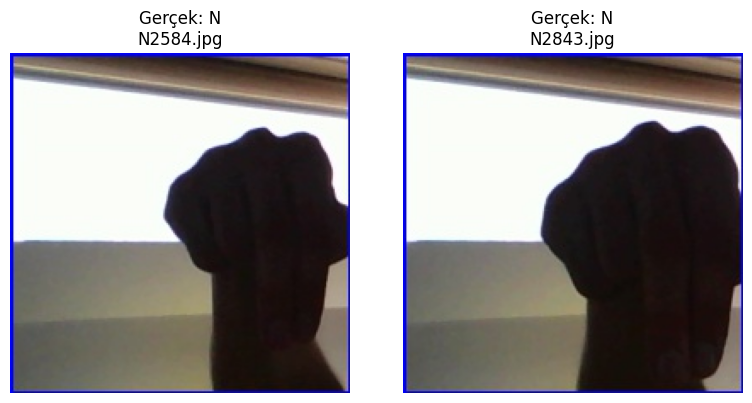

In [16]:
import matplotlib.pyplot as plt
from PIL import Image

error_files = [
    "/root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1/asl_alphabet_train/asl_alphabet_train/N/N2584.jpg",
    "/root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1/asl_alphabet_train/asl_alphabet_train/N/N2843.jpg"
]

plt.figure(figsize=(8, 4))

for i, file_path in enumerate(error_files):
    image = Image.open(file_path)

    plt.subplot(1, 2, i + 1)
    plt.imshow(image)
    plt.title(f"Gerçek: N\n{file_path.split('/')[-1]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Değişiklik**

In [23]:
import numpy as np
from PIL import Image

for file_path in error_files:

    image = Image.open(file_path).convert("RGB")
    image = image.resize((224, 224))

    img = np.array(image).astype("float32") / 255.0

    # Gamma ile aydınlat
    gamma = 0.40
    bright = np.power(img, gamma)

    # Model kendi içinde /255 yaptığı için tekrar 0-255'e çeviriyoruz
    original_input = np.expand_dims(img * 255.0, axis=0)
    bright_input   = np.expand_dims(bright * 255.0, axis=0)

    original_probs = best_model(original_input, training=False).numpy()[0]
    bright_probs   = best_model(bright_input, training=False).numpy()[0]

    original_idx = np.argmax(original_probs)
    bright_idx   = np.argmax(bright_probs)

    print("Dosya:", file_path.split("/")[-1])

    print(
        f"ORİJİNAL    → {class_names[original_idx]} "
        f"%{original_probs[original_idx] * 100:.4f}"
    )

    print(
        f"AYDINLATILMIŞ → {class_names[bright_idx]} "
        f"%{bright_probs[bright_idx] * 100:.4f}"
    )

    print("N güveni:")
    n_idx = class_to_index["N"]

    print(
        f"Orijinal %{original_probs[n_idx] * 100:.4f} | "
        f"Aydınlatılmış %{bright_probs[n_idx] * 100:.4f}"
    )

    print("=" * 50)

Dosya: N2584.jpg
ORİJİNAL    → M %80.4821
AYDINLATILMIŞ → nothing %56.4341
N güveni:
Orijinal %19.1233 | Aydınlatılmış %34.2767
Dosya: N2843.jpg
ORİJİNAL    → M %91.7998
AYDINLATILMIŞ → nothing %92.1774
N güveni:
Orijinal %8.1589 | Aydınlatılmış %2.3424


In [24]:
import tensorflow as tf
import numpy as np

n_idx = class_to_index["N"]

for file_path in error_files:

    # Eğitim/test sırasında kullandığımız işlemin AYNISI
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(
        image,
        [224, 224],
        antialias=True
    )
    image = tf.cast(image, tf.float32)

    # -----------------------------
    # ORİJİNAL
    # -----------------------------
    original_input = tf.expand_dims(image, axis=0)

    original_probs = best_model(
        original_input,
        training=False
    ).numpy()[0]

    # -----------------------------
    # AYDINLATILMIŞ
    # -----------------------------
    normalized = image / 255.0

    gamma = 0.40
    bright = tf.pow(normalized, gamma) * 255.0

    bright_input = tf.expand_dims(
        bright,
        axis=0
    )

    bright_probs = best_model(
        bright_input,
        training=False
    ).numpy()[0]

    # Tahminler
    original_idx = np.argmax(original_probs)
    bright_idx = np.argmax(bright_probs)

    print("Dosya:", file_path.split("/")[-1])

    print(
        f"ORİJİNAL      → {class_names[original_idx]} "
        f"%{original_probs[original_idx] * 100:.4f}"
    )

    print(
        f"AYDINLATILMIŞ → {class_names[bright_idx]} "
        f"%{bright_probs[bright_idx] * 100:.4f}"
    )

    print(
        f"N güveni: "
        f"Orijinal %{original_probs[n_idx] * 100:.4f} | "
        f"Aydınlatılmış %{bright_probs[n_idx] * 100:.4f}"
    )

    print("=" * 55)

Dosya: N2584.jpg
ORİJİNAL      → M %57.9306
AYDINLATILMIŞ → nothing %81.1528
N güveni: Orijinal %42.0310 | Aydınlatılmış %13.3527
Dosya: N2843.jpg
ORİJİNAL      → M %76.7250
AYDINLATILMIŞ → nothing %88.5021
N güveni: Orijinal %23.2708 | Aydınlatılmış %3.4999


In [25]:
import numpy as np
from sklearn.metrics import confusion_matrix

# N ve M sınıf indeksleri
n_index = class_to_index["N"]
m_index = class_to_index["M"]

n_total = 0
n_correct = 0
n_as_m = 0

for images, labels in test_ds:

    probs = best_model(images, training=False).numpy()
    predictions = np.argmax(probs, axis=1)

    labels_np = labels.numpy()

    for true_label, pred_label in zip(labels_np, predictions):

        if true_label == n_index:

            n_total += 1

            if pred_label == n_index:
                n_correct += 1

            if pred_label == m_index:
                n_as_m += 1


print("========== N SINIFI ANALİZİ ==========")
print("Toplam N görüntüsü :", n_total)
print("Doğru N tahmini    :", n_correct)
print("M olarak tahmin    :", n_as_m)

print()
print(f"N Accuracy : %{(n_correct / n_total) * 100:.4f}")
print(f"N → M Hata : %{(n_as_m / n_total) * 100:.4f}")

========== N SINIFI ANALİZİ ==========
Toplam N görüntüsü : 450
Doğru N tahmini    : 448
M olarak tahmin    : 2

N Accuracy : %99.5556
N → M Hata : %0.4444


In [26]:
import numpy as np
from tqdm.auto import tqdm

m_test_df = test_df[test_df["label"] == "M"].copy()

print("Kontrol edilecek M görüntüsü:", len(m_test_df))

m_test_ds = create_dataset(
    m_test_df,
    training=False
)

n_index = class_to_index["N"]
m_index = class_to_index["M"]

m_total = 0
m_correct = 0
m_as_n = 0

for images, labels in tqdm(
    m_test_ds,
    total=int(np.ceil(len(m_test_df) / BATCH_SIZE)),
    desc="M sınıfı kontrol ediliyor"
):

    probs = best_model(images, training=False).numpy()
    predictions = np.argmax(probs, axis=1)

    labels_np = labels.numpy()

    m_total += len(labels_np)
    m_correct += np.sum(predictions == m_index)
    m_as_n += np.sum(predictions == n_index)


print("\n========== M SINIFI ANALİZİ ==========")
print("Toplam M görüntüsü :", m_total)
print("Doğru M tahmini    :", m_correct)
print("N olarak tahmin    :", m_as_n)

print(f"M Accuracy : %{(m_correct / m_total) * 100:.4f}")
print(f"M → N Hata : %{(m_as_n / m_total) * 100:.4f}")

Kontrol edilecek M görüntüsü: 450


M sınıfı kontrol ediliyor:   0%|          | 0/15 [00:00<?, ?it/s]


========== M SINIFI ANALİZİ ==========
Toplam M görüntüsü : 450
Doğru M tahmini    : 450
N olarak tahmin    : 0
M Accuracy : %100.0000
M → N Hata : %0.0000


Dataset Üzerinde Denemeler

In [27]:
import kagglehub
import os

# Harici test datasetini indir
dataset_b = kagglehub.dataset_download(
    "danrasband/asl-alphabet-test"
)

print("Dataset B yolu:")
print(dataset_b)

print("\n========== KLASÖR YAPISI ==========")

for root, dirs, files in os.walk(dataset_b):
    level = root.replace(dataset_b, "").count(os.sep)

    # Çok derine gitme
    if level > 2:
        continue

    indent = "    " * level
    print(f"{indent}📁 {os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}    📄 {file}")

    if len(files) > 10:
        print(f"{indent}    ... +{len(files)-10} dosya")

100%|██████████| 24.3M/24.3M [00:01<00:00, 12.9MB/s]

Extracting files...


Dataset B yolu:
/root/.cache/kagglehub/datasets/danrasband/asl-alphabet-test/versions/1

========== KLASÖR YAPISI ==========
📁 1/
    📁 L/
        📄 L0018_test.jpg
        📄 L0016_test.jpg
        📄 L0009_test.jpg
        📄 L0021_test.jpg
        📄 L0025_test.jpg
        📄 L0015_test.jpg
        📄 L0019_test.jpg
        📄 L0003_test.jpg
        📄 L0001_test.jpg
        📄 L0007_test.jpg
        ... +20 dosya
    📁 B/
        📄 B0015_test.jpg
        📄 B0005_test.jpg
        📄 B0029_test.jpg
        📄 B0013_test.jpg
        📄 B0007_test.jpg
        📄 B0025_test.jpg
        📄 B0019_test.jpg
        📄 B0017_test.jpg
        📄 B0020_test.jpg
        📄 B0006_test.jpg
        ... +20 dosya
    📁 asl-alphabet-test/
        📁 L/
            📄 L0018_test.jpg
            📄 L0016_test.jpg
            📄 L0009_test.jpg
            📄 L0021_test.jpg
            📄 L0025_test.jpg
            📄 L0015_test.jpg
            📄 L0019_test.jpg
            📄 L0003_test.jpg
            📄 L0001_test.jpg
         

In [29]:
import os

external_test_path = os.path.join(dataset_b, "asl-alphabet-test")

classes_b = sorted([
    d for d in os.listdir(external_test_path)
    if os.path.isdir(os.path.join(external_test_path, d))
])

total_images = 0

print("========== DATASET B ==========")
print("Sınıf sayısı:", len(classes_b))
print()

for class_name in classes_b:

    class_path = os.path.join(external_test_path, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"{class_name:8} → {len(images)} görüntü")
    total_images += len(images)

print()
print("Toplam görüntü:", total_images)

print("\nDataset A sınıflarıyla aynı mı?")
print(set(classes_b) == set(class_names))

========== DATASET B ==========
Sınıf sayısı: 29

A        → 30 görüntü
B        → 30 görüntü
C        → 30 görüntü
D        → 30 görüntü
E        → 30 görüntü
F        → 30 görüntü
G        → 30 görüntü
H        → 30 görüntü
I        → 30 görüntü
J        → 30 görüntü
K        → 30 görüntü
L        → 30 görüntü
M        → 30 görüntü
N        → 30 görüntü
O        → 30 görüntü
P        → 30 görüntü
Q        → 30 görüntü
R        → 30 görüntü
S        → 30 görüntü
T        → 30 görüntü
U        → 30 görüntü
V        → 30 görüntü
W        → 30 görüntü
X        → 30 görüntü
Y        → 30 görüntü
Z        → 30 görüntü
del      → 30 görüntü
nothing  → 30 görüntü
space    → 30 görüntü

Toplam görüntü: 870

Dataset A sınıflarıyla aynı mı?
True


In [30]:
import os
import pandas as pd

external_rows = []

for class_name in classes_b:

    class_path = os.path.join(
        external_test_path,
        class_name
    )

    for file_name in os.listdir(class_path):

        if file_name.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):

            external_rows.append({
                "filepath": os.path.join(
                    class_path,
                    file_name
                ),
                "label": class_name
            })


external_df = pd.DataFrame(external_rows)

print("Harici test görüntüsü:", len(external_df))

# Eğitim/test ile AYNI preprocessing
external_ds = create_dataset(
    external_df,
    training=False
)

print("\nModel Dataset B üzerinde test ediliyor...\n")

external_loss, external_accuracy = best_model.evaluate(
    external_ds,
    verbose=1
)

print("\n========== HARİCİ TEST SONUCU ==========")
print(
    f"External Accuracy : "
    f"%{external_accuracy * 100:.4f}"
)
print(
    f"External Loss     : "
    f"{external_loss:.6f}"
)

Harici test görüntüsü: 870

Model Dataset B üzerinde test ediliyor...

28/28 ━━━━━━━━━━━━━━━━━━━━ 27s 967ms/step - accuracy: 0.1023 - loss: 21.1954

========== HARİCİ TEST SONUCU ==========
External Accuracy : %10.2299
External Loss     : 21.195354


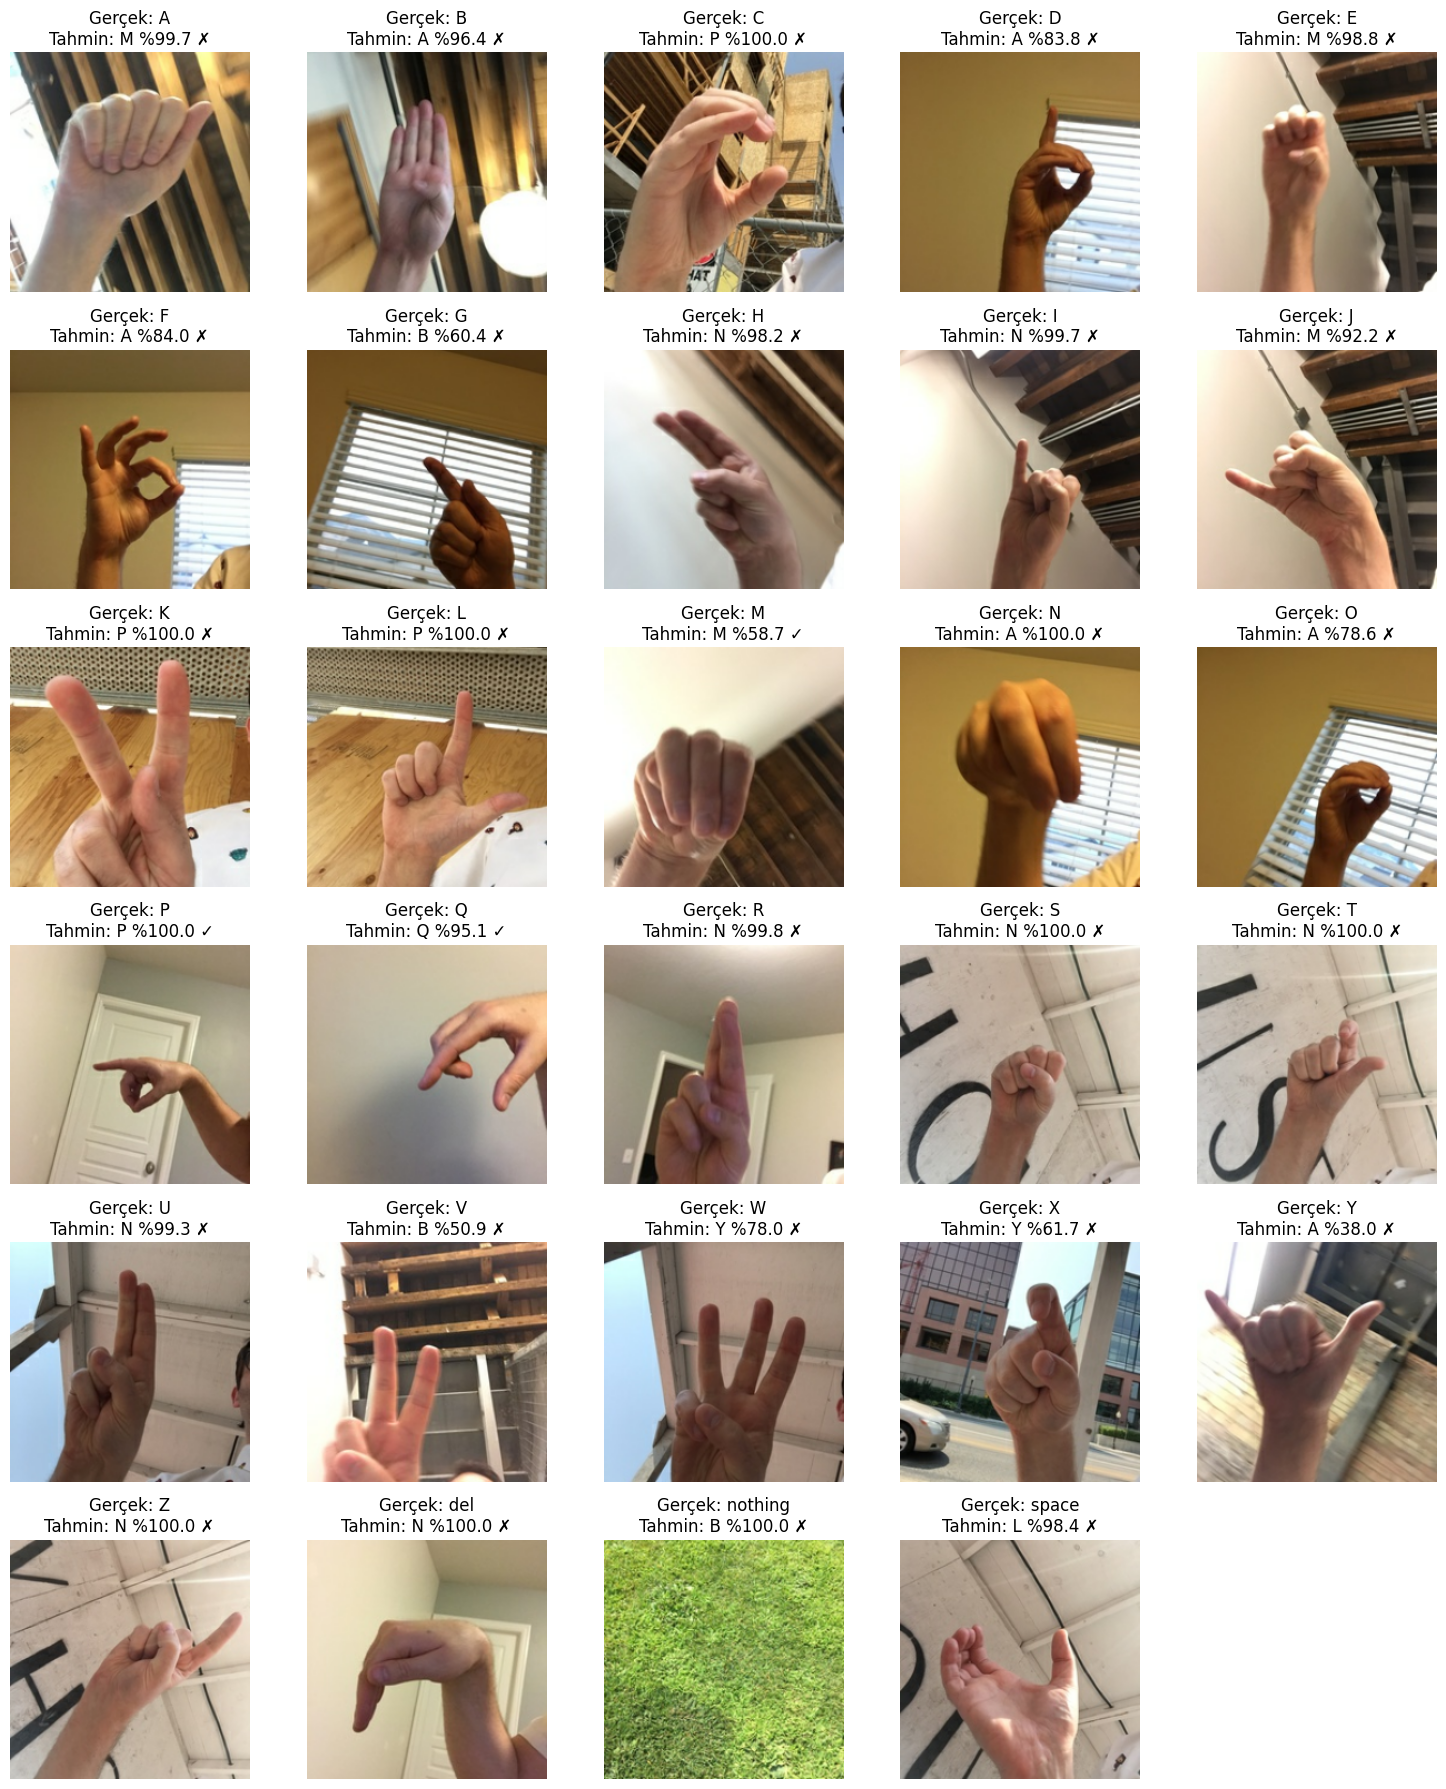

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Her sınıftan 1 tane görüntü al
samples = (
    external_df
    .groupby("label", group_keys=False)
    .sample(1, random_state=42)
    .reset_index(drop=True)
)

plt.figure(figsize=(15, 18))

for i, row in samples.iterrows():

    # HER ZAMANKİ preprocessing
    image = preprocess_image(row["filepath"])

    input_image = tf.expand_dims(image, axis=0)

    probs = best_model(
        input_image,
        training=False
    ).numpy()[0]

    pred_idx = np.argmax(probs)
    pred_class = class_names[pred_idx]
    confidence = probs[pred_idx] * 100

    plt.subplot(6, 5, i + 1)

    plt.imshow(
        tf.cast(image, tf.uint8).numpy()
    )

    correct = row["label"] == pred_class

    plt.title(
        f"Gerçek: {row['label']}\n"
        f"Tahmin: {pred_class} %{confidence:.1f}"
        + (" ✓" if correct else " ✗")
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [32]:
import tensorflow as tf

def preprocess_image(file_path):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(
        image,
        [224, 224],
        antialias=True
    )
    image = tf.cast(image, tf.float32)

    return image

print("✅ preprocess_image hazır")

✅ preprocess_image hazır


In [34]:
import numpy as np
from collections import Counter
from tqdm.auto import tqdm

external_true = []
external_pred = []

for images, labels in tqdm(
    external_ds,
    total=28,
    desc="Harici tahminler"
):

    probs = best_model(
        images,
        training=False
    ).numpy()

    preds = np.argmax(probs, axis=1)

    external_true.extend(labels.numpy())
    external_pred.extend(preds)


external_true = np.array(external_true)
external_pred = np.array(external_pred)

prediction_counts = Counter(external_pred)

print("\n========== MODEL EN ÇOK NE TAHMİN EDİYOR? ==========\n")

for class_index, count in prediction_counts.most_common():

    print(
        f"{class_names[class_index]:8} → "
        f"{count:3} görüntü "
        f"(%{count / len(external_pred) * 100:.2f})"
    )

Harici tahminler:   0%|          | 0/28 [00:00<?, ?it/s]


========== MODEL EN ÇOK NE TAHMİN EDİYOR? ==========

N        → 301 görüntü (%34.60)
P        → 203 görüntü (%23.33)
M        →  89 görüntü (%10.23)
B        →  55 görüntü (%6.32)
A        →  46 görüntü (%5.29)
S        →  41 görüntü (%4.71)
O        →  28 görüntü (%3.22)
Y        →  21 görüntü (%2.41)
E        →  15 görüntü (%1.72)
L        →  12 görüntü (%1.38)
space    →   8 görüntü (%0.92)
nothing  →   7 görüntü (%0.80)
F        →   6 görüntü (%0.69)
R        →   6 görüntü (%0.69)
Q        →   6 görüntü (%0.69)
Z        →   4 görüntü (%0.46)
H        →   4 görüntü (%0.46)
J        →   4 görüntü (%0.46)
W        →   4 görüntü (%0.46)
C        →   2 görüntü (%0.23)
D        →   2 görüntü (%0.23)
K        →   2 görüntü (%0.23)
U        →   1 görüntü (%0.11)
del      →   1 görüntü (%0.11)
I        →   1 görüntü (%0.11)
X        →   1 görüntü (%0.11)


In [35]:
import numpy as np

print("========== DATASET B SINIF BAZLI BAŞARI ==========\n")

for class_index, class_name in enumerate(class_names):

    mask = external_true == class_index

    total = np.sum(mask)

    correct = np.sum(
        external_pred[mask] == class_index
    )

    accuracy = correct / total * 100

    print(
        f"{class_name:8} → "
        f"{correct:2}/{total:2} doğru "
        f"(%{accuracy:.2f})"
    )

========== DATASET B SINIF BAZLI BAŞARI ==========

A        →  2/30 doğru (%6.67)
B        →  0/30 doğru (%0.00)
C        →  1/30 doğru (%3.33)
D        →  1/30 doğru (%3.33)
E        →  3/30 doğru (%10.00)
F        →  1/30 doğru (%3.33)
G        →  0/30 doğru (%0.00)
H        →  3/30 doğru (%10.00)
I        →  0/30 doğru (%0.00)
J        →  0/30 doğru (%0.00)
K        →  1/30 doğru (%3.33)
L        →  4/30 doğru (%13.33)
M        →  9/30 doğru (%30.00)
N        →  8/30 doğru (%26.67)
O        →  4/30 doğru (%13.33)
P        → 20/30 doğru (%66.67)
Q        →  5/30 doğru (%16.67)
R        →  0/30 doğru (%0.00)
S        →  4/30 doğru (%13.33)
T        →  0/30 doğru (%0.00)
U        →  0/30 doğru (%0.00)
V        →  0/30 doğru (%0.00)
W        →  4/30 doğru (%13.33)
X        →  0/30 doğru (%0.00)
Y        →  7/30 doğru (%23.33)
Z        →  0/30 doğru (%0.00)
del      →  0/30 doğru (%0.00)
nothing  →  7/30 doğru (%23.33)
space    →  5/30 doğru (%16.67)


In [36]:
import json
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

report_dir = "/content/drive/MyDrive/Digitra/reports"

# Classification report
external_report = classification_report(
    external_true,
    external_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(external_report).transpose()

report_path = (
    report_dir +
    "/custom_cnn_v1_external_classification_report.csv"
)

report_df.to_csv(report_path)


# Confusion matrix
external_cm = confusion_matrix(
    external_true,
    external_pred
)

cm_df = pd.DataFrame(
    external_cm,
    index=class_names,
    columns=class_names
)

cm_path = (
    report_dir +
    "/custom_cnn_v1_external_confusion_matrix.csv"
)

cm_df.to_csv(cm_path)


# Genel metrikler
metrics = {
    "model": "digitra_custom_cnn_v1",
    "internal_test_accuracy": 0.999847,
    "external_test_accuracy": float(
        (external_true == external_pred).mean()
    ),
    "external_test_images": int(len(external_true)),
    "external_dataset": "danrasband/asl-alphabet-test",
    "note": (
        "Dataset A image-level internal split performs extremely well, "
        "but external Dataset B shows severe domain shift/generalization failure."
    )
}

metrics_path = (
    report_dir +
    "/custom_cnn_v1_external_metrics.json"
)

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)


print("✅ External test raporu kaydedildi")
print(report_path)
print(cm_path)
print(metrics_path)

✅ External test raporu kaydedildi
/content/drive/MyDrive/Digitra/reports/custom_cnn_v1_external_classification_report.csv
/content/drive/MyDrive/Digitra/reports/custom_cnn_v1_external_confusion_matrix.csv
/content/drive/MyDrive/Digitra/reports/custom_cnn_v1_external_metrics.json


# MODEL 2 — EfficientNetB0 Transfer Learning
## ⭐ YARIN BURADAN DEVAM ET

Aşağıdaki hücreler yeni bir Colab oturumunda sıfırdan **devam ortamını kurar**. Üstteki 87.000 görsellik audit hücrelerini tekrar çalıştırmana gerek yok.

Sıra: **A → B → C → D → E**. Stage 1 bittikten sonra F/G bölümlerine geç.

### A — Oturumu hazırla, Drive'ı bağla ve GPU'yu kontrol et

In [ ]:
!pip install -q kagglehub

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision
from google.colab import drive

drive.mount('/content/drive')

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_PATH = "/content/drive/MyDrive/Digitra"
TRAIN_SPLIT_PATH = os.path.join(PROJECT_PATH, "splits", "train_manifest.csv")
VAL_SPLIT_PATH = os.path.join(PROJECT_PATH, "splits", "val_manifest.csv")
TEST_SPLIT_PATH = os.path.join(PROJECT_PATH, "splits", "test_manifest.csv")

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

# Colab Pro GPU'larda Tensor Core hizlandirmasi. Final softmax asagida
# float32 birakilir; checkpoint ve olasilik ciktilari kararli kalir.
mixed_precision.set_global_policy("mixed_float16" if gpus else "float32")

gpu_name = (
    tf.config.experimental.get_device_details(gpus[0]).get("device_name", "Bilinmiyor")
    if gpus else "YOK"
)
print("TensorFlow:", tf.__version__)
print("GPU:", gpu_name)
print("Compute policy:", mixed_precision.global_policy().name)
print("✅ Oturum temel ayarları hazır")

### B — Dataset A'yı runtime'a getir ve kayıtlı splitleri geri yükle

Bu hücre **audit yapmaz**. Sadece görüntü dosyalarını runtime'a getirir ve Drive'daki mevcut split manifestlerinin yollarını yeni runtime'a göre düzeltir.

In [ ]:
import kagglehub

dataset_a = kagglehub.dataset_download("grassknoted/asl-alphabet")
train_path = os.path.join(dataset_a, "asl_alphabet_train", "asl_alphabet_train")

for p in [TRAIN_SPLIT_PATH, VAL_SPLIT_PATH, TEST_SPLIT_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Split manifesti bulunamadı: {p}")

def repair_runtime_paths(df):
    df = df.copy()
    if "filename" not in df.columns or "label" not in df.columns:
        raise ValueError("Split manifestinde filename/label sütunları bulunamadı.")
    df["filepath"] = df.apply(
        lambda row: os.path.join(train_path, str(row["label"]), str(row["filename"])),
        axis=1
    )
    return df

train_df = repair_runtime_paths(pd.read_csv(TRAIN_SPLIT_PATH))
val_df   = repair_runtime_paths(pd.read_csv(VAL_SPLIT_PATH))
test_df  = repair_runtime_paths(pd.read_csv(TEST_SPLIT_PATH))

print("✅ Splitler geri yüklendi")
print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))
print("İlk dosya mevcut mu:", os.path.exists(train_df.iloc[0]["filepath"]))

### C — Tek ve tutarlı preprocessing + tf.data + augmentation

Train, validation, test ve sonraki tek-görsel tahminlerinde aynı resize/preprocessing zinciri kullanılır.

In [ ]:
class_names = sorted(train_df["label"].unique())
class_to_index = {name: i for i, name in enumerate(class_names)}
index_to_class = {i: name for name, i in class_to_index.items()}
NUM_CLASSES = len(class_names)

def load_image(file_path, label):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE], antialias=True)
    image = tf.cast(image, tf.float32)
    return image, label

def preprocess_image(file_path):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE], antialias=True)
    return tf.cast(image, tf.float32)

def create_dataset(dataframe, training=False):
    paths = dataframe["filepath"].astype(str).values
    labels_np = dataframe["label"].map(class_to_index).values.astype("int32")
    ds = tf.data.Dataset.from_tensor_slices((paths, labels_np))
    if training:
        ds = ds.shuffle(5000, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=4)
    ds = ds.batch(BATCH_SIZE, drop_remainder=False)
    ds = ds.prefetch(1)
    return ds

train_ds = create_dataset(train_df, training=True)
val_ds   = create_dataset(val_df, training=False)
test_ds  = create_dataset(test_df, training=False)

data_augmentation = keras.Sequential([
    layers.RandomRotation(0.05, seed=SEED),
    layers.RandomTranslation(0.05, 0.05, seed=SEED),
    layers.RandomZoom(0.10, 0.10, seed=SEED),
    layers.RandomContrast(0.10, seed=SEED),
], name="data_augmentation")

print("✅ Pipeline hazır")
print("Sınıf sayısı:", NUM_CLASSES)
print("Batch size:", BATCH_SIZE)

### D — EfficientNetB0'ı oluştur veya Drive'daki son checkpoint'ten devam et

Öncelik: `latest_model.keras` → `best_model.keras` → yeni ImageNet EfficientNetB0.

In [ ]:
MODEL_DIR = os.path.join(PROJECT_PATH, "models", "digitra-efficientnetb0-v1.0.0")
os.makedirs(MODEL_DIR, exist_ok=True)

BEST_EFF_PATH = os.path.join(MODEL_DIR, "best_model.keras")
LATEST_EFF_PATH = os.path.join(MODEL_DIR, "latest_model.keras")
EFF_LOG_PATH = os.path.join(PROJECT_PATH, "logs", "digitra_efficientnetb0_v1_training.csv")

def build_frozen_efficientnet():
    base = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")
    x = data_augmentation(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
    x = layers.Dropout(0.30, name="classifier_dropout")(x)
    outputs = layers.Dense(
        NUM_CLASSES, activation="softmax", dtype="float32", name="classifier"
    )(x)
    model = keras.Model(inputs, outputs, name="digitra_efficientnetb0_v1")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    return model

resume_path = LATEST_EFF_PATH if os.path.exists(LATEST_EFF_PATH) else (BEST_EFF_PATH if os.path.exists(BEST_EFF_PATH) else None)

if resume_path:
    efficientnet_model = keras.models.load_model(resume_path)
    print("✅ Checkpoint yüklendi:", resume_path)
else:
    efficientnet_model = build_frozen_efficientnet()
    print("✅ Yeni EfficientNetB0 oluşturuldu")

if os.path.exists(EFF_LOG_PATH):
    try:
        old_log = pd.read_csv(EFF_LOG_PATH)
        INITIAL_EPOCH = len(old_log)
    except Exception:
        INITIAL_EPOCH = 0
else:
    INITIAL_EPOCH = 0

print("Tamamlanmış epoch:", INITIAL_EPOCH)
print("Model:", efficientnet_model.name)
print("Trainable params:", int(sum(np.prod(v.shape) for v in efficientnet_model.trainable_weights)))
print("Non-trainable params:", int(sum(np.prod(v.shape) for v in efficientnet_model.non_trainable_weights)))

### E — Callback'ler ve Stage 1 eğitimi

**GPU önerilir.** Eğitim hücresi GPU yoksa bilerek başlamaz; böylece yanlışlıkla saatlerce CPU eğitimi çalışmaz.

Stage 1: EfficientNet gövdesi dondurulmuş halde sınıflandırıcı başlığını eğit. Hedef toplam **10 epoch**; EarlyStopping daha önce de durdurabilir.

In [ ]:
best_checkpoint = keras.callbacks.ModelCheckpoint(
    BEST_EFF_PATH, monitor="val_loss", save_best_only=True, verbose=1
)
latest_checkpoint = keras.callbacks.ModelCheckpoint(
    LATEST_EFF_PATH, save_best_only=False, verbose=0
)
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1
)
csv_logger = keras.callbacks.CSVLogger(EFF_LOG_PATH, append=True)

efficientnet_callbacks = [
    best_checkpoint, latest_checkpoint, early_stopping, reduce_lr, csv_logger
]

print("✅ Callback sistemi hazır")
print("Best  :", BEST_EFF_PATH)
print("Latest:", LATEST_EFF_PATH)
print("Log   :", EFF_LOG_PATH)

In [ ]:
STAGE1_TOTAL_EPOCHS = 10

gpus = tf.config.list_physical_devices("GPU")
if not gpus:
    print("❌ GPU yok. Stage 1 eğitimi başlatılmadı.")
    print("Colab → Çalışma zamanı → Çalışma zamanı türünü değiştir → T4 GPU")
elif INITIAL_EPOCH >= STAGE1_TOTAL_EPOCHS:
    print(f"✅ Stage 1 zaten tamamlanmış: {INITIAL_EPOCH}/{STAGE1_TOTAL_EPOCHS} epoch")
else:
    print("✅ GPU:", gpus)
    print(f"Stage 1 devam ediyor: epoch {INITIAL_EPOCH} → {STAGE1_TOTAL_EPOCHS}")
    history_eff_stage1 = efficientnet_model.fit(
        train_ds,
        validation_data=val_ds,
        initial_epoch=INITIAL_EPOCH,
        epochs=STAGE1_TOTAL_EPOCHS,
        callbacks=efficientnet_callbacks
    )

## F — Stage 1 bittikten sonra: en iyi checkpoint'i doğrula

Bu hücre yalnızca Stage 1 bittikten sonra çalıştırılır. **Dataset B burada kullanılmaz.**

In [ ]:
if not os.path.exists(BEST_EFF_PATH):
    raise FileNotFoundError("best_model.keras henüz yok; önce Stage 1 eğitimini tamamla.")

best_eff_model = keras.models.load_model(BEST_EFF_PATH)
val_loss_eff, val_acc_eff = best_eff_model.evaluate(val_ds, verbose=1)

print()
print("===== EFFICIENTNET STAGE 1 / VALIDATION =====")
print(f"Val Accuracy : %{val_acc_eff * 100:.4f}")
print(f"Val Loss     : {val_loss_eff:.6f}")

## G — Fine-tuning (Stage 2) — Stage 1 tamamlanmadan çalıştırma

EfficientNet'in son bölümünü düşük öğrenme oranıyla açar. Fine-tuning kararları yalnızca Dataset A train/validation üzerinden verilir. **Dataset B'ye bakarak ayar değiştirme.**

In [ ]:
fine_model = keras.models.load_model(BEST_EFF_PATH)
base_model = fine_model.get_layer("efficientnetb0")
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

fine_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

FINE_DIR = os.path.join(PROJECT_PATH, "models", "digitra-efficientnetb0-v1.0.0-finetuned")
os.makedirs(FINE_DIR, exist_ok=True)
FINE_BEST_PATH = os.path.join(FINE_DIR, "best_model.keras")
FINE_LATEST_PATH = os.path.join(FINE_DIR, "latest_model.keras")
FINE_LOG_PATH = os.path.join(PROJECT_PATH, "logs", "digitra_efficientnetb0_v1_finetune.csv")

fine_callbacks = [
    keras.callbacks.ModelCheckpoint(FINE_BEST_PATH, monitor="val_loss", save_best_only=True, verbose=1),
    keras.callbacks.ModelCheckpoint(FINE_LATEST_PATH, save_best_only=False, verbose=0),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    keras.callbacks.CSVLogger(FINE_LOG_PATH, append=True)
]

print("✅ Fine-tuning modeli hazır")
print("Trainable params:", int(sum(np.prod(v.shape) for v in fine_model.trainable_weights)))
print("Learning rate: 1e-5")

In [ ]:
FINE_TUNE_EPOCHS = 10

gpus = tf.config.list_physical_devices("GPU")
if not gpus:
    print("❌ GPU yok. Fine-tuning başlatılmadı.")
else:
    fine_initial_epoch = 0
    if os.path.exists(FINE_LOG_PATH):
        try:
            fine_initial_epoch = len(pd.read_csv(FINE_LOG_PATH))
        except Exception:
            fine_initial_epoch = 0

    if fine_initial_epoch > 0 and os.path.exists(FINE_LATEST_PATH):
        fine_model = keras.models.load_model(FINE_LATEST_PATH)
        print("✅ Fine-tuning checkpoint yüklendi:", FINE_LATEST_PATH)

    if fine_initial_epoch >= FINE_TUNE_EPOCHS:
        print(f"✅ Fine-tuning zaten tamamlanmış: {fine_initial_epoch}/{FINE_TUNE_EPOCHS}")
    else:
        print(f"Fine-tuning devam ediyor: epoch {fine_initial_epoch} → {FINE_TUNE_EPOCHS}")
        history_eff_fine = fine_model.fit(
            train_ds,
            validation_data=val_ds,
            initial_epoch=fine_initial_epoch,
            epochs=FINE_TUNE_EPOCHS,
            callbacks=fine_callbacks
        )

## H — Model 2 tamamlandıktan sonra final değerlendirme

Önce **Dataset A internal test**, ardından bir kez **Dataset B external test** çalıştır. Dataset B hiçbir aşamada eğitim/fine-tuning verisi değildir.

In [ ]:
FINAL_EFF_PATH = FINE_BEST_PATH if "FINE_BEST_PATH" in globals() and os.path.exists(FINE_BEST_PATH) else BEST_EFF_PATH
final_eff_model = keras.models.load_model(FINAL_EFF_PATH)

internal_loss, internal_acc = final_eff_model.evaluate(test_ds, verbose=1)
print()
print("===== MODEL 2 / INTERNAL TEST =====")
print(f"Accuracy : %{internal_acc * 100:.4f}")
print(f"Loss     : {internal_loss:.6f}")
print("Model    :", FINAL_EFF_PATH)

In [ ]:
# HARİCİ TEST — yalnızca final model seçildikten sonra çalıştır.
import json

dataset_b = kagglehub.dataset_download("danrasband/asl-alphabet-test")
external_test_path = os.path.join(dataset_b, "asl-alphabet-test")

external_rows = []
for class_name in sorted(os.listdir(external_test_path)):
    class_path = os.path.join(external_test_path, class_name)
    if not os.path.isdir(class_path):
        continue
    for file_name in os.listdir(class_path):
        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            external_rows.append({"filepath": os.path.join(class_path, file_name), "label": class_name})

external_df = pd.DataFrame(external_rows)
if set(external_df["label"].unique()) != set(class_names):
    raise ValueError("Dataset B sınıfları Model 2 sınıflarıyla eşleşmiyor.")

external_ds = create_dataset(external_df, training=False)
external_loss, external_acc = final_eff_model.evaluate(external_ds, verbose=1)

print()
print("===== MODEL 2 / EXTERNAL TEST =====")
print("Görüntü  :", len(external_df))
print(f"Accuracy : %{external_acc * 100:.4f}")
print(f"Loss     : {external_loss:.6f}")

REPORT_DIR = os.path.join(PROJECT_PATH, "reports")
os.makedirs(REPORT_DIR, exist_ok=True)
metrics = {
    "model": "digitra_efficientnetb0_v1",
    "final_model_path": FINAL_EFF_PATH,
    "internal_test_accuracy": float(internal_acc),
    "internal_test_loss": float(internal_loss),
    "external_test_accuracy": float(external_acc),
    "external_test_loss": float(external_loss),
    "external_test_images": int(len(external_df)),
    "external_dataset": "danrasband/asl-alphabet-test",
    "external_dataset_used_for_training": False
}
metrics_path = os.path.join(REPORT_DIR, "efficientnetb0_v1_final_metrics.json")
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)
print("✅ Final metrikler kaydedildi:", metrics_path)